# SciPy Bootcamp — Week 1, Day 2

##### Sampling, CLT & Confidence Intervals
##### Standard error, CLT demonstration, t-intervals, bootstrap
##### Dataset: Simulated MedPulse article read time data
##### Suggested dataset: kaggle.com/datasets/snapcrack/all-the-news (article metadata)
##### Q1 Demonstrate the Central Limit Theorem: create a heavily right-skewed population (use np.random.exponential(scale=3, size=100000) to simulate MedPulse session durations). Take 2000 samples of sizes n=5, n=30, n=100. Plot the distribution of sample means for each. What do you observe as n increases?
##### Q2 Calculate the standard error for different sample sizes (n=10, 50, 100, 500, 1000) from the population in Q1. Print a table of n vs SE. What is the relationship between sample size and standard error?
##### Q3 A sample of 25 MedPulse articles has a mean read time of 4.3 minutes and std of 1.8 minutes. Compute the 90%, 95%, and 99% confidence intervals for the true mean read time. Print all three and explain in one sentence why the 99% CI is wider.
##### Q4 Bootstrap confidence interval: given the array of article read times [2.1,3.4,1.8,4.2,2.9,5.1,3.3,2.7,4.8,3.1,2.5,4.4,3.8,1.9,5.5], compute a 95% bootstrap CI for the MEDIAN (not the mean) using 10,000 bootstrap samples. Compare it to the observed median.
##### Q5 Sample size planning: you want to estimate the mean MedPulse session duration with a margin of error of ±15 seconds at 95% confidence. Based on a pilot sample std of 85 seconds, calculate the required sample size using the formula n = (z * sigma / E)^2. Then verify it empirically by simulating 1000 samples of that size and checking what % of CIs contain the true mean.

In [3]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("pariza/bbc-news-summary")

print("Path to dataset files:", path)

100%|██████████| 8.91M/8.91M [00:01<00:00, 7.59MB/s]

Extracting files...


Path to dataset files: C:\Users\user\.cache\kagglehub\datasets\pariza\bbc-news-summary\versions\2


In [1]:
import numpy as np
import pandas as pd
from scipy import stats
import statsmodels.formula.api as smf
import warnings
warnings.filterwarnings('ignore')

In [ ]:
import pandas as pd
import os

# Point to the downloaded folder
data_path = r'C:\Users\user\.cache\kagglehub\datasets\pariza\bbc-news-summary\versions\2'

# See what files are in there
for root, dirs, files in os.walk(data_path):
    for file in files[:10]:  # show first 10 files
        print(os.path.join(root, file))

In [6]:
# Path to the News Articles folder
articles_path = r'C:\Users\user\.cache\kagglehub\datasets\pariza\bbc-news-summary\versions\2\BBC News Summary\News Articles'

# Load all articles into a DataFrame
records = []
for category in os.listdir(articles_path):
    cat_path = os.path.join(articles_path, category)
    if os.path.isdir(cat_path):
        for filename in os.listdir(cat_path):
            filepath = os.path.join(cat_path, filename)
            with open(filepath, 'r', encoding='utf-8', errors='ignore') as f:
                text = f.read()
            records.append({
                'category' : category,
                'filename' : filename,
                'text'     : text,
                'word_count': len(text.split()),
                'char_count': len(text)
            })

df = pd.DataFrame(records)

print(df.shape)
print(df['category'].value_counts())
display(df.head())

(2225, 5)
category
sport            511
business         510
politics         417
tech             401
entertainment    386
Name: count, dtype: int64


,category,filename,text,word_count,char_count
0,business,001.txt,Ad sales boost Time Warner profit\n\nQuarterly...,421,2559
1,business,002.txt,Dollar gains on Greenspan speech\n\nThe dollar...,384,2252
2,business,003.txt,Yukos unit buyer faces loan claim\n\nThe owner...,264,1551
3,business,004.txt,High fuel prices hit BA's profits\n\nBritish A...,406,2401
4,business,005.txt,Pernod takeover talk lifts Domecq\n\nShares in...,265,1569


In [ ]:
# Q1 Demonstrate the Central Limit Theorem: create a heavily right-skewed population 
# (use np.random.exponential(scale=3, size=100000) to simulate MedPulse session durations). 
# Take 2000 samples of sizes n=5, n=30, n=100. 
# Plot the distribution of sample means for each. 
# What do you observe as n increases?

In [8]:
population_1 = np.random.exponential(scale=3,size=100000)

In [14]:
sample_1_mean_1 = [np.mean(np.random.choice(population_1, size=5)) for i in range(2000)]
sample_1_mean_2 = [np.mean(np.random.choice(population_1, size=30)) for i in range(2000)]
sample_1_mean_3 = [np.mean(np.random.choice(population_1, size=100)) for i in range(2000)]

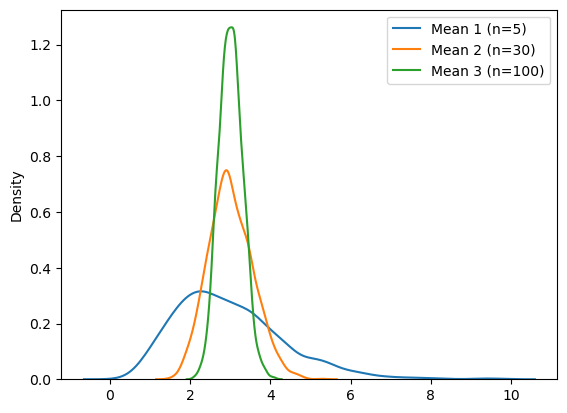

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.kdeplot(sample_1_mean_1, label = 'Mean 1 (n=5)')
sns.kdeplot(sample_1_mean_2, label = 'Mean 2 (n=30)')
sns.kdeplot(sample_1_mean_3, label = 'Mean 3 (n=100)')
plt.legend()
plt.show()

As n increases, the sampling distribution of the sample mean approachhes the normal distribution, which is right-skewed 

In [ ]:
# Q2 Calculate the standard error for different sample sizes (n=10, 50, 100, 500, 1000) from the population in Q1. 
# Print a table of n vs SE. 
# What is the relationship between sample size and standard error?

In [48]:
np.random.seed(420)
n_list = [10,50,100,500,1000]
se_list = []
for n in n_list:
    sample_means = [np.mean(np.random.choice(population_1, size=n)) for i in range(2000)]
    se_list.append(np.std(sample_means))

display(pd.DataFrame({'n':n_list,'SE':se_list}))

,n,SE
0,10,0.965873
1,50,0.423289
2,100,0.304244
3,500,0.133655
4,1000,0.093567


As n increases, SE gets smaller

In [ ]:
# Q3 A sample of 25 MedPulse articles has a mean read time of 4.3 minutes and std of 1.8 minutes. 
# Compute the 90%, 95%, and 99% confidence intervals for the true mean read time. 
# Print all three and explain in one sentence why the 99% CI is wider.

In [49]:
np.random.seed(420)
n = 25
mean = 4.3
std = 1.8
se = std / np.sqrt(n) 
ci_list = [.90, .95, .99]
for i in ci_list:
    ci = stats.t.interval(confidence=i, df=n-1, loc=mean, scale=se)
    print(f'{i*100}% CI: ({ci[0]:.2f}, {ci[1]:.2f})')

90.0% CI: (3.68, 4.92)
95.0% CI: (3.56, 5.04)
99.0% CI: (3.29, 5.31)


In [ ]:
Explain in one sentence why the 99% CI is wider: 
The 99% CI is wider because capturing 99% of outcomes requires a larger t-critical value, 
which expands both ends of the interval.

In [ ]:
# Q4 Bootstrap confidence interval: given the array of article read times [2.1,3.4,1.8,4.2,2.9,5.1,3.3,2.7,4.8,3.1,2.5,4.4,3.8,1.9,5.5], 
# compute a 95% bootstrap CI for the MEDIAN (not the mean) using 10,000 bootstrap samples. Compare it to the observed median.

In [42]:
read_times = [2.1,3.4,1.8,4.2,2.9,5.1,3.3,2.7,4.8,3.1,2.5,4.4,3.8,1.9,5.5]
observed_med = np.median(read_times)
boot_mean = stats.bootstrap((read_times,), np.median, confidence_level=0.95, n_resamples=10000, method='percentile')
print(f'The observed Median is {observed_med} and 95% bootstrap CI for the median is from {boot_mean.confidence_interval.low:.2f} to {boot_mean.confidence_interval.high:.2f}')

The observed Median is 3.3 and 95% bootstrap CI for the median is from 2.50 to 4.20


In [ ]:
# Q5 Sample size planning: you want to estimate the mean MedPulse session duration with a margin of error of ±15 seconds at 95% confidence. 
# Based on a pilot sample std of 85 seconds, calculate the required sample size using the formula n = (z * sigma / E)^2. 
# Then verify it empirically by simulating 1000 samples of that size and checking what % of CIs contain the true mean.

In [46]:
import math

# Calculate the required sample size
z = stats.norm.ppf(0.975) # 2 tails
sigma =  85
E = 15
n_required = math.ceil((z * sigma / E) ** 2)
print(f'Required sample size: {n_required}')

Required sample size: 124


In [47]:
# verify emperically

true_mean  = 120   # seconds — the population mean we're estimating
n_sims     = 1000
contained  = 0

for i in range(n_sims):
    # Draw a sample of the required size
    sample = np.random.normal(loc=true_mean, scale=sigma, size=n_required)
    
    # Compute 95% CI for this sample
    ci = stats.t.interval(
        confidence=0.95,
        df=n_required - 1,
        loc=sample.mean(),
        scale=stats.sem(sample)
    )
    
    # Check if the true mean falls inside this CI
    if ci[0] <= true_mean <= ci[1]:
        contained += 1

pct_contained = contained / n_sims * 100
print(f'% of CIs containing true mean: {pct_contained:.1f}%')
print(f'Expected: ~95% — Difference: {abs(95 - pct_contained):.1f}pp')

% of CIs containing true mean: 94.8%
Expected: ~95% — Difference: 0.2pp
